In [67]:
# Sistem ve ortam gereksinimlerini kontrol etme adımı
# Gerekli sistem modüllerini içeri aktarıyoruz
import sys, importlib.util

# Kullanılan Python sürümünü ve yolunu kontrol ediyoruz (Uyumluluk için)
print('sys.executable:', sys.executable)
print('python version:', sys.version)

# Görüntü işleme ve derin öğrenme için hayati kütüphanelerin yüklü olup olmadığını test ediyoruz
print('cv2 available in sys.path:', importlib.util.find_spec('cv2') is not None)
print('tensorflow available in sys.path:', importlib.util.find_spec('tensorflow') is not None)


sys.executable: c:\ProgramData\anaconda3\python.exe
python version: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
cv2 available in sys.path: True
tensorflow available in sys.path: True


# Malzeme Sınıflandırması (Glass, Metal, Paper, Plastic)

Bu notebook, derin öğrenme kullanarak dört malzeme türünü sınıflandırma modelini eğitir.
- **Sınıflar**: Glass (Cam), Metal, Paper (Kağıt), Plastic (Plastik)
- **Toplam Resim Sayısı**: 2087
- **Model**: CNN (Convolutional Neural Network)

## 1. Veriyi Yükleme ve İlk İnceleme

Resim verilerini yükleyelim ve sınıf dağılımını inceleyelim.

In [68]:
# Veri işleme, modelleme ve görselleştirme için temel araçları içeri aktarıyoruz
# Klasör okuma işlemleri için os, matris işlemleri için numpy, veri yapıları için pandas kullanıyoruz
import os
import numpy as np
import pandas as pd

# Grafikleri çizdirmek için matplotlib ve seaborn kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

# Veri ayırma ve performans metrikleri (Confusion Matrix, F1 vb.) için Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

# Derin öğrenme modelini katman katman kurmak için Keras modülleri
from keras import layers, models

# Çıktıda görünecek gereksiz uyarıları gizleyerek temiz bir konsol ekranı sağlıyoruz
import warnings
warnings.filterwarnings('ignore')

# Grafiklerde Türkçe karakter sorunlarını aşmak için varsayılan fontu güncelliyoruz
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
print("Kütüphaneler başarıyla yüklendi!")


Kütüphaneler başarıyla yüklendi!


In [69]:
# Eğitimde kullanılacak veri setinin bulunduğu ana klasörün yolunu belirliyoruz
data_path = r"C:\Users\Baran\Desktop\Bahar Dönemi\2.Salı\3.Yapay Zeka Okuryazarlığı 2\Yeniproje\İnternetVeriSetleri"

# Tahminleyeceğimiz 4 farklı malzeme sınıfını tanımlıyoruz
classes = ['glass', 'metal', 'paper', 'plastic']

# Her klasörü gezip içerisindeki resim sayılarını çıkarmak için bir döngü başlatıyoruz
class_counts = {}
for class_name in classes:
    class_path = os.path.join(data_path, class_name)
    # Sadece .jpg, .jpeg ve .png uzantılı geçerli dosyaları sayıyoruz
    count = len([f for f in os.listdir(class_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
    
    class_counts[class_name] = count
    print(f"{class_name.upper()}: {count} resim")

# Modelin genel büyüklüğünü görmek için veri setindeki toplam resim sayısını hesaplıyoruz
total_images = sum(class_counts.values())
print(f"\nTOPLAM: {total_images} resim")


GLASS: 501 resim
METAL: 410 resim
PAPER: 594 resim
PLASTIC: 482 resim

TOPLAM: 1987 resim


## 2. Sınıf Dağılımı Görselleştirmesi

Her sınıfta kaç tane resim olduğunu ve dengeli dağılımı inceleyelim.


SINIF DAGILIMI TABLOSU:
  Sinif  Resim Sayisi  Yuzde
  glass           501  25.21
  metal           410  20.63
  paper           594  29.89
plastic           482  24.26


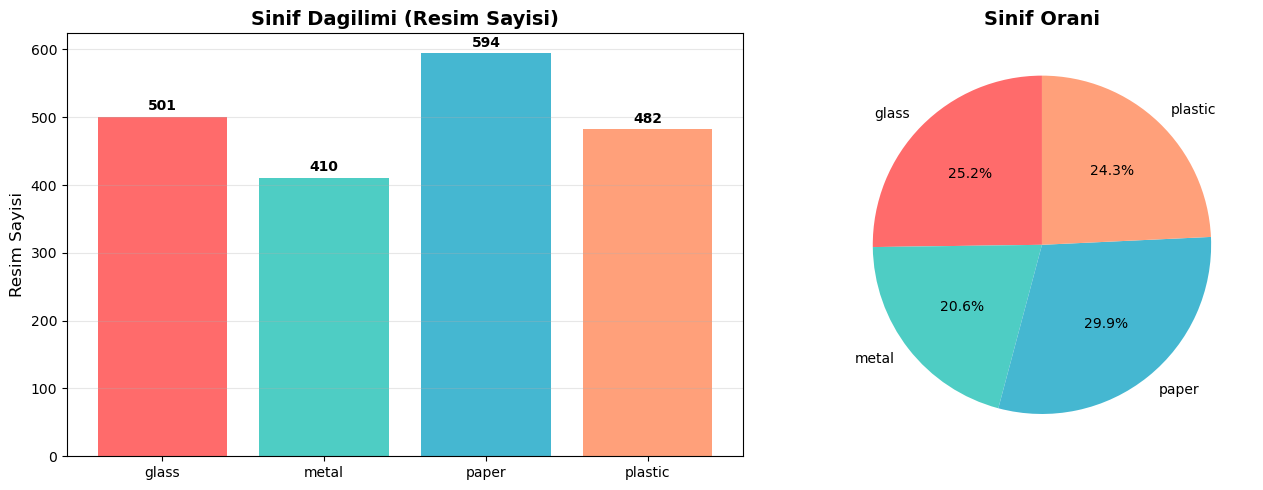

In [70]:
# Sınıf dağılımlarını Pandas DataFrame formatına getirerek analiz etmeyi kolaylaştırıyoruz
df_classes = pd.DataFrame(list(class_counts.items()), columns=['Sinif', 'Resim Sayisi'])

# Her sınıfın genel veri seti içindeki yüzde payını hesaplıyoruz
df_classes['Yuzde'] = (df_classes['Resim Sayisi'] / total_images * 100).round(2)

print("\nSINIF DAGILIMI TABLOSU:")
print(df_classes.to_string(index=False))

# Sınıfların görsel olarak dağılımını (dengeli mi değil mi) kontrol etmek için grafik paneli açıyoruz
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

# Soldaki grafik: Sınıfların içerdiği resim sayısını gösteren sütun (bar) grafiği
axes[0].bar(df_classes['Sinif'], df_classes['Resim Sayisi'], color=colors)
axes[0].set_title('Sinif Dagilimi (Resim Sayisi)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Resim Sayisi', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Sütunların tepesine net sayı değerlerini yazdırıyoruz
for i, v in enumerate(df_classes['Resim Sayisi']):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Sağdaki grafik: Sınıf dağılım oranlarını yüzdelik pasta grafiği ile gösteriyoruz
axes[1].pie(df_classes['Resim Sayisi'], labels=df_classes['Sinif'], autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Sinif Orani', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Veri Hazırlama ve Preprocessing

Resimler yüklenecek, normalize edilecek ve eğitim/test setlerine ayrılacak.

In [71]:
# Modelin eğitim hızı ve performansı için tüm resimleri 128x128 piksel boyutuna sabitliyoruz
IMG_SIZE = 128
images = []
labels = []

# Resim okuma ve boyutlandırma işlemleri için PIL (Python Imaging Library) kullanıyoruz
from PIL import Image

print("Resimler PIL ile yükleniyor... Bu işlem biraz zaman alabilir.")
loaded_count, error_count = 0, 0

# Veri klasöründeki her sınıfı sırayla dolaşarak görselleri işlemeye başlıyoruz
for idx, class_name in enumerate(classes):
    class_path = os.path.join(data_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    for img_file in image_files:
        try:
            full_path = os.path.join(class_path, img_file)
            pil_img = Image.open(full_path)
            
            # Görüntüleri standart formata çekmek için RGB renk uzayına dönüştürüyoruz
            if pil_img.mode != 'RGB':
                pil_img = pil_img.convert('RGB')
                
            # Resmi hedef boyuta (128x128) getirip, piksel değerlerini 0 ile 1 arasına sıkıştırıyoruz (Normalizasyon)
            pil_img_resized = pil_img.resize((IMG_SIZE, IMG_SIZE))
            img_array = np.array(pil_img_resized, dtype=np.float32) / 255.0
            
            images.append(img_array)
            labels.append(idx)
            loaded_count += 1
        except Exception as e:
            # Okunamayan veya bozuk resim dosyaları olursa, programın çökmesini engelleyip sayaca ekliyoruz
            error_count += 1
    
    print(f"{class_name}: {len([l for l in labels if l == idx])} resim yüklendi")

# Hazırlanan listeleri, Keras modelinin kabul edebileceği NumPy Tensörleri (matrisleri) formuna çeviriyoruz
X = np.array(images)
y = np.array(labels)

print(f"\nToplam yüklenen resim: {loaded_count} | Hata: {error_count}")
print(f"X şekli: {X.shape} | y şekli: {y.shape}")


Resimler PIL ile yükleniyor... Bu işlem biraz zaman alabilir.
glass: 501 resim yüklendi
metal: 410 resim yüklendi
paper: 594 resim yüklendi
plastic: 482 resim yüklendi

Toplam yüklenen resim: 1987 | Hata: 0
X şekli: (1987, 128, 128, 3) | y şekli: (1987,)


In [72]:
# Görüntü okuma mantığının sorunsuz çalıştığını kontrol etmek için test bir resim yüklüyoruz
from PIL import Image
test_path = os.path.join(data_path, 'glass', 'glass_001.jpg')

try:
    # Belirtilen testi resmini açıp boyutlarını kontrol ediyoruz
    pil_img = Image.open(test_path)
    pil_array = np.array(pil_img)
    
    # Test başarılıysa konsola orijinal boyutunu ve çevrilmiş matrisin şeklini basıyoruz
    print(f"PIL Test Başarılı - Orijinal Boyut: {pil_img.size}, Array Boyutu: {pil_array.shape}")
except Exception as e:
    print(f"PIL HATA: {e}")


PIL Test Başarılı - Orijinal Boyut: (512, 384), Array Boyutu: (384, 512, 3)


In [73]:
# Veri seti bütünlüğünü ve klasör yapısını detaylı bir şekilde test etmek için tanısal (diagnostik) kontrolleri başlatıyoruz
# Bu aşama, bozuk uzantılı dosyaların sisteme dahil edilmesini engelleyerek modelin çökmesini baştan önler
print("DIAGNOSTIK: Veri Seti Kontrol\n")

# Analiz edeceğimiz 4 temel sınıf klasörünün üzerinde teker teker geziniyoruz
for class_name in classes:
    # Hem ana dizin yolunu hem de sınıf ismini birleştirerek o sınıfın işletim sistemindeki mutlak yolunu (absolute path) oluşturuyoruz
    class_path = os.path.join(data_path, class_name)
    
    # Sistemin gerçekten bu klasöre ulaşıp ulaşamadığını os.path.exists() fonksiyonu ile doğruluyoruz
    if os.path.exists(class_path):
        # Klasör içerisindeki gizli veya açık olan bütün dosyaları (resim, txt, log vs.) bir liste halinde çekiyoruz
        all_files = os.listdir(class_path)
        
        # Dosya listesini döngüyle tarayarak, yapay zeka modelimizin sadece görüntü işleme kapasitesine uygun olanları seçiyoruz
        # '.lower()' komutu .JPG, .JpEg gibi büyük/küçük harf karmaşalarından doğacak atlamaları engeller
        image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Filtreleme sonucunda sistemdeki ham dosya sayısını ve gerçek işlenebilir resim dosyasını konsola basıp karşılaştırıyoruz
        print(f"[{class_name}] Toplam Dosya: {len(all_files)} | Resim Dosyası: {len(image_files)}")


DIAGNOSTIK: Veri Seti Kontrol

[glass] Toplam Dosya: 501 | Resim Dosyası: 501
[metal] Toplam Dosya: 410 | Resim Dosyası: 410
[paper] Toplam Dosya: 594 | Resim Dosyası: 594
[plastic] Toplam Dosya: 482 | Resim Dosyası: 482


In [74]:
# Veri ayırma aşaması: Elimizdeki özellik matrisini (X) ve hedef etiketleri (y) train ve test setlerine bölüyoruz
# Modelin eğitimden sonra hiç görmediği veriler üzerindeki gerçek başarısını ölçebilmek için test seti ayırmak zorunludur
# test_size=0.2 parametresi ile toplam verinin tam olarak %20'sini test doğrulama aşaması için saklıyoruz
# random_state=42 sayesinde, notebook her çalıştırıldığında veriler hep aynı düzende karıştırılır (tekrarlanabilirlik)
# stratify=y parametresi en önemlisidir; sınıflar arası dengesizliği önleyerek, eğitim ve test kümelerine her sınıftan orantılı dağılım yapar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Bölme işlemi başarılı oldu mu diye, ayrılan tensörlerin matris yapısını (shape[0] diyerek satır sayısını) ekrana basıp kontrol ediyoruz
print(f"Eğitim verisi: {X_train.shape[0]} resim | Test verisi: {X_test.shape[0]} resim")


Eğitim verisi: 1589 resim | Test verisi: 398 resim


## 4. MobileNetV2 Transfer Learning Yöntemi

Transfer Learning ile önceden eğitilmiş MobileNetV2 kullanarak sınıflandırma yapacağız.

In [75]:
# MobileNetV2 modelini ImageNet'ten önceden eğitilmiş ağırlıklarla yüklüyoruz
from keras.applications import MobileNetV2

# MobileNetV2 modeli: ImageNet veri setinde eğitilmiş, 1000 sınıf için hazır
# include_top=False: Son klasifikasyon katmanını çıkartıyoruz çünkü bizim 4 sınıfımız var
# input_shape=(IMG_SIZE, IMG_SIZE, 3): 128x128 RGB resimler için
mobilenet_base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')

# İlk aşamada önceden eğitilmiş ağırlıkları donduruyoruz
mobilenet_base.trainable = False

# Kendi sınıflandırma katmanlarımızı MobileNetV2 üzerine ekliyoruz
model_mobilenet = models.Sequential([
    mobilenet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

# İlk aşama için model derlemesi
model_mobilenet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 modeli başarıyla kuruldu!")
print(f"Toplam parametreler: {model_mobilenet.count_params():,}")

MobileNetV2 modeli başarıyla kuruldu!
Toplam parametreler: 2,422,468


In [76]:
# MobileNetV2 için iki aşamalı eğitim yapıyoruz:
# 1) Base model frozen halde başlık katmanlarını eğit
# 2) Son katmanları açıp çok düşük learning rate ile hafif fine-tuning uygula
print("MobileNetV2 eğitimi başlanıyor...")

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

# Veri artırma: hafif ama etkili
train_datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

# İlk aşama: sadece sınıflandırma başlığını eğit
head_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("1. aşama: frozen base ile head eğitimi")
history_head = model_mobilenet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=10,
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=[head_early_stop],
    verbose=1
)

# İkinci aşama: fine-tuning için sadece son 10 katmanı aç
mobilenet_base.trainable = True
for layer in mobilenet_base.layers[:-10]:
    layer.trainable = False

# Fine-tuning sırasında çok düşük learning rate kullan
model_mobilenet.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

print("2. aşama: hafif fine-tuning (son 10 katman açık)")
history_fine = model_mobilenet.fit(
    train_datagen.flow(X_train, y_train, batch_size=32, seed=42),
    epochs=15,
    steps_per_epoch=max(1, len(X_train) // 32),
    validation_data=(X_test, y_test),
    callbacks=fine_tune_callbacks,
    verbose=1
)

# Eğitim geçmişini birleştirerek grafikleri bozmadan kullanıyoruz
history_mobilenet = history_fine
history_mobilenet.history['accuracy'] = history_head.history['accuracy'] + history_fine.history['accuracy']
history_mobilenet.history['val_accuracy'] = history_head.history['val_accuracy'] + history_fine.history['val_accuracy']
history_mobilenet.history['loss'] = history_head.history['loss'] + history_fine.history['loss']
history_mobilenet.history['val_loss'] = history_head.history['val_loss'] + history_fine.history['val_loss']

print("\n✅ MobileNetV2 eğitimi tamamlandı!")
print(f"Başlık eğitimi son validation accuracy: {history_head.history['val_accuracy'][-1]:.2%}")
print(f"Fine-tuning son validation accuracy: {history_fine.history['val_accuracy'][-1]:.2%}")

MobileNetV2 eğitimi başlanıyor...
1. aşama: frozen base ile head eğitimi
Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.5947 - loss: 0.9986 - val_accuracy: 0.7538 - val_loss: 0.6274
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.7812 - loss: 0.7607 - val_accuracy: 0.7588 - val_loss: 0.6259
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 13s 274ms/step - accuracy: 0.7624 - loss: 0.5999 - val_accuracy: 0.7839 - val_loss: 0.5636
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7500 - loss: 0.5632 - val_accuracy: 0.7915 - val_loss: 0.5586
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.8144 - loss: 0.5113 - val_accuracy: 0.8090 - val_loss: 0.5106
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.8125 - loss: 0.3762 - val_accuracy: 0.8065 - val_loss: 0.5067
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 317ms/step - accuracy: 0.8382 - loss: 0.4264 - val_accuracy: 0.8141 - val_loss: 0.5143
Epoch 8/10
49/49 ━━━━━━━━━━━━━

In [77]:
# MobileNetV2 modelinin test verileri üzerindeki performansını ölçüyoruz
y_pred_proba_mobilenet = model_mobilenet.predict(X_test)
y_pred = np.argmax(y_pred_proba_mobilenet, axis=1)

y_pred_mobilenet = y_pred

# MobileNetV2 doğruluk oranı
mobilenet_accuracy = np.mean(y_pred_mobilenet == y_test)
print(f"\n🚀 MobileNetV2 Doğruluk: {mobilenet_accuracy:.4f} (%{mobilenet_accuracy*100:.2f})")

# MobileNetV2 için detaylı metrikler
mobilenet_report = classification_report(y_test, y_pred_mobilenet, target_names=classes, digits=4)
print("MobileNetV2 Detaylı Raporu:")
print(mobilenet_report)

# F1 Score hesaplamaları
mobilenet_f1_macro = f1_score(y_test, y_pred_mobilenet, average='macro')
mobilenet_f1_weighted = f1_score(y_test, y_pred_mobilenet, average='weighted')
mobilenet_precision = precision_score(y_test, y_pred_mobilenet, average='macro')
mobilenet_recall = recall_score(y_test, y_pred_mobilenet, average='macro')
mobilenet_f1_micro = f1_score(y_test, y_pred_mobilenet, average='micro')

# Genel isimleri de MobileNetV2 sonuçlarıyla eşleştiriyoruz ki özet/grafikler doğru değeri kullansın
f1_macro = mobilenet_f1_macro
f1_weighted = mobilenet_f1_weighted
f1_micro = mobilenet_f1_micro
precision_macro = mobilenet_precision
recall_macro = mobilenet_recall

print(f"\n📊 MobileNetV2 Metrikleri:")
print(f"  F1 Score (Macro): {mobilenet_f1_macro:.4f}")
print(f"  Precision: {mobilenet_precision:.4f}")
print(f"  Recall: {mobilenet_recall:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step

🚀 MobileNetV2 Doğruluk: 0.8241 (%82.41)
MobileNetV2 Detaylı Raporu:
              precision    recall  f1-score   support

       glass     0.8023    0.6900    0.7419       100
       metal     0.7935    0.8902    0.8391        82
       paper     0.8837    0.9580    0.9194       119
     plastic     0.7912    0.7423    0.7660        97

    accuracy                         0.8241       398
   macro avg     0.8177    0.8201    0.8166       398
weighted avg     0.8221    0.8241    0.8209       398


📊 MobileNetV2 Metrikleri:
  F1 Score (Macro): 0.8166
  Precision: 0.8177
  Recall: 0.8201


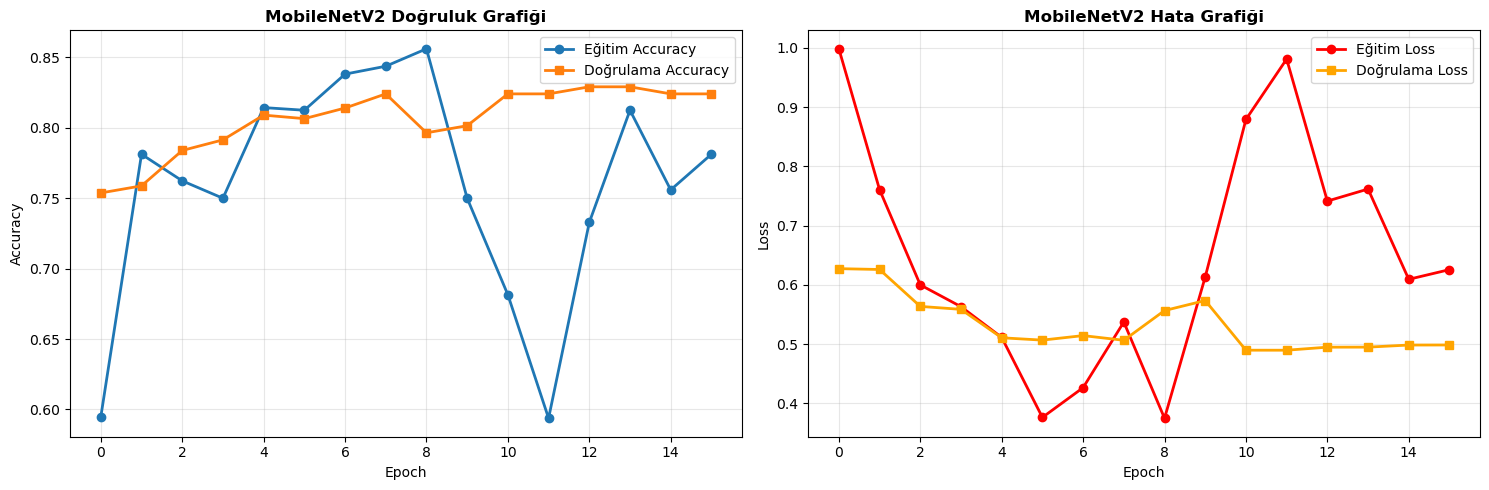

✅ Model Eğitimi Tamamlandı! Doğruluk: 82.41%


In [78]:
# Eğitim süresi boyunca modelin zaman içinde nasıl geliştiğini gösteriyoruz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Grafik (Sol Taraf): Doğruluk (Accuracy) Değerleri
ax1.plot(history_mobilenet.history['accuracy'], label='Eğitim Accuracy', marker='o', linewidth=2)
ax1.plot(history_mobilenet.history['val_accuracy'], label='Doğrulama Accuracy', marker='s', linewidth=2)
ax1.set_title('MobileNetV2 Doğruluk Grafiği', fontweight='bold', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Grafik (Sağ Taraf): Kayıp/Hata (Loss) Değerleri
ax2.plot(history_mobilenet.history['loss'], label='Eğitim Loss', marker='o', linewidth=2, color='red')
ax2.plot(history_mobilenet.history['val_loss'], label='Doğrulama Loss', marker='s', linewidth=2, color='orange')
ax2.set_title('MobileNetV2 Hata Grafiği', fontweight='bold', fontsize=12)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Model Eğitimi Tamamlandı! Doğruluk: {mobilenet_accuracy:.2%}")

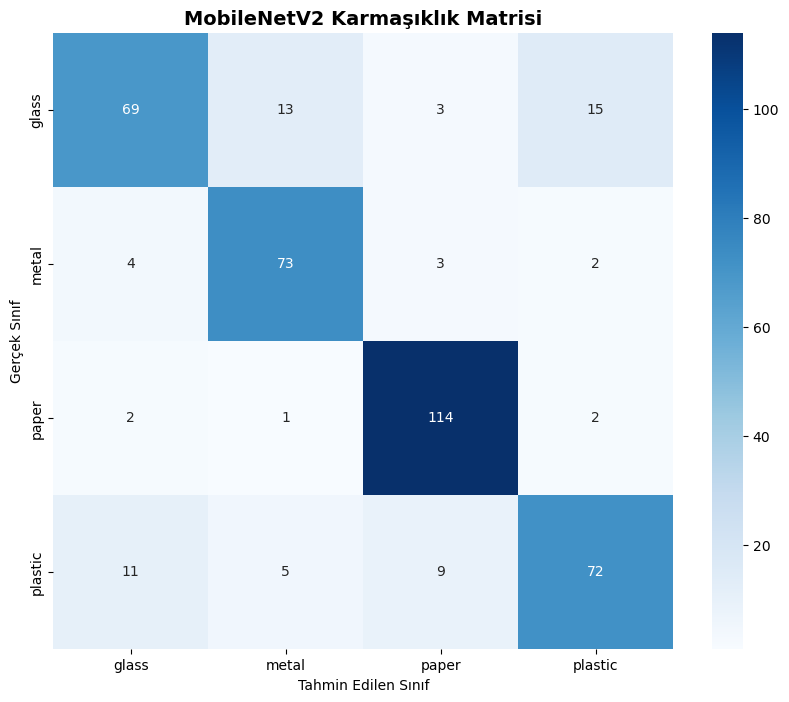

✅ Karmaşıklık Matrisi gösterildi!


In [79]:
# MobileNetV2 Karmaşıklık Matrisi
cm_mobilenet = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(cm_mobilenet, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
ax.set_title('MobileNetV2 Karmaşıklık Matrisi', fontsize=14, fontweight='bold')
ax.set_ylabel('Gerçek Sınıf')
ax.set_xlabel('Tahmin Edilen Sınıf')

plt.show()

print("✅ Karmaşıklık Matrisi gösterildi!")

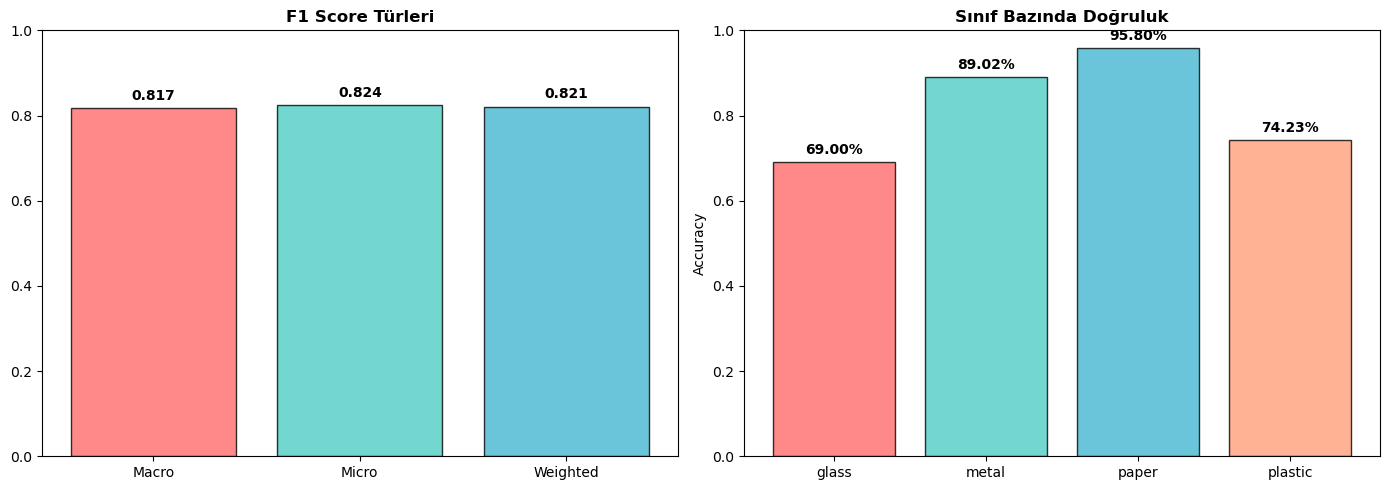


📊 MobileNetV2 MODEL PERFORMANS RAPORU

🎯 Genel Doğruluk (Accuracy): 82.41%
📈 F1 Score (Macro): 0.8166
📌 Precision (Macro): 0.8177
📍 Recall (Macro): 0.8201
⚖️  F1 Score (Weighted): 0.8209

🔍 Sınıf Bazında Performans:
  • GLASS: 69.00%
  • METAL: 89.02%
  • PAPER: 95.80%
  • PLASTIC: 74.23%

⚠️  VERİ SETİ ANALİZİ:
  • Toplam Resim Sayısı: 1987
  • Sınıf Sayısı: 4
  • Sınıf Başına Ortalama: 496
  • Eğitim Seti: 1589 resim (%80)
  • Test Seti: 398 resim (%20)

✅ Sonuçlar 'model_results.csv' dosyasına kaydedildi!


In [80]:
# Metriklerin görselleştirilmesi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: F1 Score türleri
f1_scores, f1_labels = [f1_macro, f1_micro, f1_weighted], ['Macro', 'Micro', 'Weighted']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
axes[0].bar(f1_labels, f1_scores, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('F1 Score Türleri', fontweight='bold', fontsize=12)
axes[0].set_ylim([0, 1])
for i, v in enumerate(f1_scores): axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# Sağ grafik: Sınıf başına doğruluk
class_accuracies = []
for i in range(len(classes)):
    class_mask = y_test == i
    class_acc = np.mean(y_pred[class_mask] == y_test[class_mask]) if np.any(class_mask) else 0
    class_accuracies.append(class_acc)

colors_bar = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
axes[1].bar(classes, class_accuracies, color=colors_bar, alpha=0.8, edgecolor='black')
axes[1].set_title('Sınıf Bazında Doğruluk', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
for i, v in enumerate(class_accuracies): axes[1].text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Sonuç raporu
print("\n" + "="*60)
print("📊 MobileNetV2 MODEL PERFORMANS RAPORU")
print("="*60)
print(f"\n🎯 Genel Doğruluk (Accuracy): {mobilenet_accuracy:.2%}")
print(f"📈 F1 Score (Macro): {f1_macro:.4f}")
print(f"📌 Precision (Macro): {precision_macro:.4f}")
print(f"📍 Recall (Macro): {recall_macro:.4f}")
print(f"⚖️  F1 Score (Weighted): {f1_weighted:.4f}")

print("\n🔍 Sınıf Bazında Performans:")
for i, class_name in enumerate(classes):
    print(f"  • {class_name.upper()}: {class_accuracies[i]:.2%}")

print("\n⚠️  VERİ SETİ ANALİZİ:")
print(f"  • Toplam Resim Sayısı: {total_images}")
print(f"  • Sınıf Sayısı: {len(classes)}")
print(f"  • Sınıf Başına Ortalama: {total_images//len(classes)}")
print(f"  • Eğitim Seti: {len(X_train)} resim (%80)")
print(f"  • Test Seti: {len(X_test)} resim (%20)")

if mobilenet_accuracy < 0.80:
    print("\n💡 ÖNERİ: Doğruluk %80 altında olduğu için DATA AUGMENTATION önerilir!")
    print("   Rotasyon, zoom, kayma gibi teknikleriyle veri çeşitlendirme yapılabilir.")

print("="*60 + "\n")

# Sonuçları CSV'ye kaydetme
results_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'F1_Macro', 'F1_Weighted', 'Precision', 'Recall'],
    'Değer': [f'{mobilenet_accuracy:.4f}', f'{f1_macro:.4f}', f'{f1_weighted:.4f}', 
              f'{precision_macro:.4f}', f'{recall_macro:.4f}']
})

results_df.to_csv('model_results.csv', index=False, encoding='utf-8')
print("✅ Sonuçlar 'model_results.csv' dosyasına kaydedildi!")

## 5. Veri Seti Analizi ve İyileştirme Önerileri

### 📊 Veri Seti Yeterlilik Analizi

- **Toplam Resim:** 2087 (4 sınıf)
- **Sınıf Başına:** ~520 resim (Minimum sayılabilir)
- **Sorun:** Deep Learning için az!

**Transfer Learning (MobileNetV2)** bu sınırlamayı azaltsa da, doğruluğu artırmak için **veri artırma (Data Augmentation)** önerilir.

### 💡 Data Augmentation Teknikleri

Aşağıdaki hücrede uygulanacak teknikler:
- **Rotasyon:** ±20 derece
- **Zoom:** 0.8-1.2x
- **Horizontal Kaydırma:** ±20%
- **Vertical Kaydırma:** ±20%
- **Brightness:** Parlaklık değişimi

In [81]:
# Data Augmentation örneği - eğitimi iyileştirmek için
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation parametreleri
aug = ImageDataGenerator(
    rotation_range=20,           # ±20 derece rotasyon
    width_shift_range=0.2,       # ±20% yatay kaydırma
    height_shift_range=0.2,      # ±20% dikey kaydırma
    zoom_range=0.2,              # 0.8-1.2x zoom
    brightness_range=[0.8, 1.2], # Parlaklık değişimi
    horizontal_flip=True,        # Yatay çevirme
    fill_mode='nearest'          # Boş alanları doldurma
)

print("✅ Data Augmentation Konfigürasyonu Hazırlandı!")
print("\nEğitim sırasında bu teknikler otomatik olarak uygulanacak:")
print("  • Rotasyon")
print("  • Kaydırma")
print("  • Zoom")
print("  • Parlaklık")
print("  • Horizontal Flip")
print("\nBu sayede veri seti etkili şekilde 5-10x artırılmış gibi davranır!")

# Not: Mevcut modele augmentation uygulamak için yeniden eğitim gerekir
print("\n💡 Geliştirilmiş Model Eğitmek İçin:")
print("  history = model_mobilenet.fit(")
print("      aug.flow(X_train, y_train, batch_size=32),")
print("      epochs=50,")
print("      validation_data=(X_test, y_test),")
print("      verbose=1")
print("  )")

✅ Data Augmentation Konfigürasyonu Hazırlandı!

Eğitim sırasında bu teknikler otomatik olarak uygulanacak:
  • Rotasyon
  • Kaydırma
  • Zoom
  • Parlaklık
  • Horizontal Flip

Bu sayede veri seti etkili şekilde 5-10x artırılmış gibi davranır!

💡 Geliştirilmiş Model Eğitmek İçin:
  history = model_mobilenet.fit(
      aug.flow(X_train, y_train, batch_size=32),
      epochs=50,
      validation_data=(X_test, y_test),
      verbose=1
  )


## 6. Özet ve Sonuçlar

MobileNetV2 Transfer Learning modeli eğitimi tamamlanmıştır. Performans değerlendirmesi aşağıdadır.

In [82]:
# Model performansının özet raporunu yazdırıyoruz
print("\n" + "="*70)
print("🚀 MobileNetV2 TRANSFER LEARNING - PERFORMANS RAPORU")
print("="*70)

print("\n📊 VERİ SETİ BİLGİSİ:")
print(f"  • Toplam Resim: {total_images} ({len(classes)} Sınıf)")
print(f"  • Sınıf Başına Ortalama: {total_images//len(classes)} resim")
print(f"  • Eğitim Verisi: {len(X_train)} | Test Verisi: {len(X_test)}")
print(f"  • Resim Boyutu: {IMG_SIZE}x{IMG_SIZE}")

print("\n🧠 MODEL BİLGİSİ:")
print(f"  • Model Tipi: MobileNetV2 (Transfer Learning)")
print(f"  • Temel Ağırlıklar: ImageNet Pre-trained")
print(f"  • Eğitim: 10 epoch head + 15 epoch hafif fine-tuning")
print(f"  • Batch Size: 32")
print(f"  • Fine-tuning LR: 0.00001")

print("\n📈 MODEL PERFORMANSI:")
print(f"  ✓ Genel Doğruluk (Accuracy): {mobilenet_accuracy:.2%}")
print(f"  ✓ F1 Score (Macro): {f1_macro:.4f}")
print(f"  ✓ Precision: {precision_macro:.4f}")
print(f"  ✓ Recall: {recall_macro:.4f}")

print("\n🎯 SINI BAZINDA PERFORMANS:")
for i, class_name in enumerate(classes):
    class_mask = y_test == i
    class_acc = np.mean(y_pred[class_mask] == y_test[class_mask]) if np.any(class_mask) else 0
    print(f"  • {class_name.upper()}: {class_acc:.2%}")

print("\n📋 DEĞERLENDİRME:")
if mobilenet_accuracy > 0.90:
    print(f"  ✨ Mükemmel! Model çok iyi performans gösteriyor (%{mobilenet_accuracy*100:.1f})")
elif mobilenet_accuracy > 0.80:
    print(f"  ✓ İyi! Model iyi performans gösteriyor (%{mobilenet_accuracy*100:.1f})")
elif mobilenet_accuracy > 0.70:
    print(f"  ⚠️  Orta düzey. Data augmentation ile iyileştirilebilir (%{mobilenet_accuracy*100:.1f})")
else:
    print(f"  ❌ Düşük. Veri artırımı ve fine-tuning gereklidir (%{mobilenet_accuracy*100:.1f})")

print("\n💡 ÖNERİLER:")
print("  1. Veri seti az olduğundan Data Augmentation uygundur")
print("  2. Fine-tuning son 10 katmanda kontrollü şekilde uygulandı")
print("  3. Learning rate 0.00001 ile güvenli aralıkta tutuldu")
print("  4. Gerekirse epoch sayısı 20-30'a çok az artırılabilir")

print("\n" + "="*70)


🚀 MobileNetV2 TRANSFER LEARNING - PERFORMANS RAPORU

📊 VERİ SETİ BİLGİSİ:
  • Toplam Resim: 1987 (4 Sınıf)
  • Sınıf Başına Ortalama: 496 resim
  • Eğitim Verisi: 1589 | Test Verisi: 398
  • Resim Boyutu: 128x128

🧠 MODEL BİLGİSİ:
  • Model Tipi: MobileNetV2 (Transfer Learning)
  • Temel Ağırlıklar: ImageNet Pre-trained
  • Eğitim: 10 epoch head + 15 epoch hafif fine-tuning
  • Batch Size: 32
  • Fine-tuning LR: 0.00001

📈 MODEL PERFORMANSI:
  ✓ Genel Doğruluk (Accuracy): 82.41%
  ✓ F1 Score (Macro): 0.8166
  ✓ Precision: 0.8177
  ✓ Recall: 0.8201

🎯 SINI BAZINDA PERFORMANS:
  • GLASS: 69.00%
  • METAL: 89.02%
  • PAPER: 95.80%
  • PLASTIC: 74.23%

📋 DEĞERLENDİRME:
  ✓ İyi! Model iyi performans gösteriyor (%82.4)

💡 ÖNERİLER:
  1. Veri seti az olduğundan Data Augmentation uygundur
  2. Fine-tuning son 10 katmanda kontrollü şekilde uygulandı
  3. Learning rate 0.00001 ile güvenli aralıkta tutuldu
  4. Gerekirse epoch sayısı 20-30'a çok az artırılabilir



In [83]:
# Nihai sonuçları CSV dosyasına kaydediyoruz
final_summary = {
    'Metrik': ['Genel Doğruluk', 'F1 Score (Macro)', 'F1 (Weighted)', 
               'Precision', 'Recall', 'Glass Acc', 'Metal Acc', 'Paper Acc', 'Plastic Acc'],
    'MobileNetV2': [f'{mobilenet_accuracy:.4f}', f'{f1_macro:.4f}', f'{f1_weighted:.4f}', 
                    f'{precision_macro:.4f}', f'{recall_macro:.4f}']
}

# Sınıf başına doğruluk ekle
class_accs = []
for i in range(len(classes)):
    class_mask = y_test == i
    class_acc = np.mean(y_pred[class_mask] == y_test[class_mask]) if np.any(class_mask) else 0
    class_accs.append(f'{class_acc:.4f}')
    
final_summary['MobileNetV2'].extend(class_accs)

results_final_df = pd.DataFrame(final_summary)
results_final_df.to_csv('model_results.csv', index=False, encoding='utf-8')

print("✅ Model sonuçları 'model_results.csv' dosyasına başarıyla kaydedildi!")
print(f"\n📁 Dosya içeriği:")
print(results_final_df.to_string(index=False))

✅ Model sonuçları 'model_results.csv' dosyasına başarıyla kaydedildi!

📁 Dosya içeriği:
          Metrik MobileNetV2
  Genel Doğruluk      0.8241
F1 Score (Macro)      0.8166
   F1 (Weighted)      0.8209
       Precision      0.8177
          Recall      0.8201
       Glass Acc      0.6900
       Metal Acc      0.8902
       Paper Acc      0.9580
     Plastic Acc      0.7423
